In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("7_real_estate_prices.csv")

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   listing_date                15000 non-null  object 
 1   property_type               15000 non-null  object 
 2   city                        15000 non-null  object 
 3   neighborhood_tier           15000 non-null  object 
 4   zipcode_crime_rate          15000 non-null  float64
 5   school_rating               15000 non-null  int64  
 6   distance_to_downtown_miles  15000 non-null  float64
 7   walk_score                  15000 non-null  int64  
 8   bedrooms                    15000 non-null  int64  
 9   bathrooms                   15000 non-null  float64
 10  square_feet                 15000 non-null  float64
 11  lot_size_sqft               15000 non-null  int64  
 12  stories                     15000 non-null  int64  
 13  garage_spaces               150

In [10]:
df.describe()

,zipcode_crime_rate,school_rating,distance_to_downtown_miles,walk_score,bedrooms,bathrooms,square_feet,lot_size_sqft,stories,garage_spaces,year_built,house_age,years_since_renovation,days_on_market,interest_rate,hoa_fees,sale_price,was_renovated
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,2.924115,6.993933,8.067307,54.130133,3.367600,2.393467,2145.734333,7930.426933,1.748400,1.601267,1982.066400,41.933600,28.633667,29.671667,6.503533,83.500600,7.827253e+05,0.433000
std,2.922573,1.499838,7.818909,19.631552,1.116969,0.772889,519.340630,7697.859543,0.620583,0.911665,24.337798,24.337798,23.718430,29.775319,0.804532,131.075489,1.622376e+05,0.495507
min,0.000000,2.000000,0.500000,10.000000,1.000000,1.000000,248.000000,1000.000000,1.000000,0.000000,1940.000000,1.000000,1.000000,1.000000,3.050000,-109.000000,1.449700e+05,0.000000
25%,0.870000,6.000000,2.300000,41.000000,3.000000,2.000000,1812.000000,2275.750000,1.000000,1.000000,1961.000000,20.000000,10.000000,8.000000,5.950000,0.000000,6.715468e+05,0.000000
50%,2.030000,7.000000,5.600000,54.000000,3.000000,2.500000,2145.000000,5527.000000,2.000000,2.000000,1983.000000,41.000000,20.000000,21.000000,6.510000,0.000000,7.799125e+05,0.000000
75%,4.032500,8.000000,11.100000,68.000000,4.000000,3.000000,2481.000000,10823.250000,2.000000,2.000000,2004.000000,63.000000,45.000000,42.000000,7.040000,183.000000,8.913538e+05,1.000000
max,31.190000,10.000000,40.000000,100.000000,6.000000,4.000000,4154.000000,50000.000000,3.000000,3.000000,2023.000000,84.000000,84.000000,301.000000,9.740000,673.000000,1.372699e+06,1.000000


In [4]:
df.isnull().sum()

property_id                      0
listing_date                     0
property_type                    0
city                             0
neighborhood_tier                0
zipcode_crime_rate               0
school_rating                    0
distance_to_downtown_miles       0
walk_score                       0
bedrooms                         0
bathrooms                        0
square_feet                    750
lot_size_sqft                    0
stories                          0
garage_spaces                    0
year_built                       0
house_age                        0
has_basement                     0
has_pool                         0
overall_condition                0
kitchen_quality                  0
hvac_condition                   0
roof_condition                   0
renovation_year               8505
years_since_renovation           0
days_on_market                   0
listing_season                   0
market_trend                     0
interest_rate       

In [5]:
df["square_feet"] = df["square_feet"].fillna(df["square_feet"].median())
df["hoa_fees"] = df["hoa_fees"].fillna(0)
df["was_renovated"] = df["renovation_year"].notnull().astype(int)

In [6]:
df.drop("renovation_year",axis = 1,inplace = True)
df.drop("property_id",axis = 1,inplace = True)

In [18]:
df.isnull().sum()

property_type                 0
city                          0
neighborhood_tier             0
zipcode_crime_rate            0
school_rating                 0
distance_to_downtown_miles    0
walk_score                    0
bedrooms                      0
bathrooms                     0
square_feet                   0
lot_size_sqft                 0
stories                       0
garage_spaces                 0
year_built                    0
house_age                     0
has_basement                  0
has_pool                      0
overall_condition             0
kitchen_quality               0
hvac_condition                0
roof_condition                0
years_since_renovation        0
days_on_market                0
listing_season                0
market_trend                  0
interest_rate                 0
has_fireplace                 0
has_patio_deck                0
has_security_system           0
hoa_fees                      0
sale_price                    0
high_val

In [11]:
for col in df.select_dtypes(include="object").columns:
    print(col, df[col].nunique())

listing_date 365
property_type 4
city 5
neighborhood_tier 4
has_basement 2
has_pool 2
overall_condition 4
kitchen_quality 4
hvac_condition 4
roof_condition 4
listing_season 4
market_trend 3
has_fireplace 2
has_patio_deck 2
has_security_system 2
high_value_property 2


In [12]:
df["listing_date"] = pd.to_datetime(df["listing_date"])

C:\Users\Safirudin\AppData\Local\Temp\ipykernel_5180\1439737229.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["listing_date"] = pd.to_datetime(df["listing_date"])


In [13]:
df["listing_year"] = df["listing_date"].dt.year
df["listing_month"] = df["listing_date"].dt.month
df["listing_day"] = df["listing_date"].dt.day

In [16]:
df = df.drop("listing_date", axis=1)

CREATING NEW FEATURE CALLED AGE_CATEGORY

In [43]:
df['age_category'] = pd.cut(
    df['house_age'],
    bins=[0,10,30,60,100],
    labels=['New','Moderate','Old','Very Old']
)

CREATING NEW FEARURE CALLED TOTAL_ROOMS

In [30]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["house_age"] = 2025 - df["year_built"]

In [33]:
df = pd.get_dummies(df,drop_first = True)

In [34]:
df.columns

Index(['zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles',
       'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft',
       'stories', 'garage_spaces', 'year_built', 'house_age',
       'years_since_renovation', 'days_on_market', 'interest_rate', 'hoa_fees',
       'sale_price', 'was_renovated', 'listing_year', 'listing_month',
       'listing_day', 'total_rooms', 'property_type_Multi-Family',
       'property_type_Single Family', 'property_type_Townhouse', 'city_Austin',
       'city_Denver', 'city_Phoenix', 'city_Seattle',
       'neighborhood_tier_Developing', 'neighborhood_tier_Good',
       'neighborhood_tier_Premium', 'has_basement_Yes', 'has_pool_Yes',
       'overall_condition_Fair', 'overall_condition_Good',
       'overall_condition_Poor', 'kitchen_quality_Basic',
       'kitchen_quality_Good', 'kitchen_quality_Premium',
       'hvac_condition_Good', 'hvac_condition_New', 'hvac_condition_Old',
       'roof_condition_Good', 'roof_condition_

In [36]:
df.columns = (df.columns.str.strip().str.lower())
print(df.columns)

Index(['zipcode_crime_rate', 'school_rating', 'distance_to_downtown_miles',
       'walk_score', 'bedrooms', 'bathrooms', 'square_feet', 'lot_size_sqft',
       'stories', 'garage_spaces', 'year_built', 'house_age',
       'years_since_renovation', 'days_on_market', 'interest_rate', 'hoa_fees',
       'sale_price', 'was_renovated', 'listing_year', 'listing_month',
       'listing_day', 'total_rooms', 'property_type_multi-family',
       'property_type_single family', 'property_type_townhouse', 'city_austin',
       'city_denver', 'city_phoenix', 'city_seattle',
       'neighborhood_tier_developing', 'neighborhood_tier_good',
       'neighborhood_tier_premium', 'has_basement_yes', 'has_pool_yes',
       'overall_condition_fair', 'overall_condition_good',
       'overall_condition_poor', 'kitchen_quality_basic',
       'kitchen_quality_good', 'kitchen_quality_premium',
       'hvac_condition_good', 'hvac_condition_new', 'hvac_condition_old',
       'roof_condition_good', 'roof_condition_

Text(0.5, 1.0, 'Square Feet vs Sale Price')

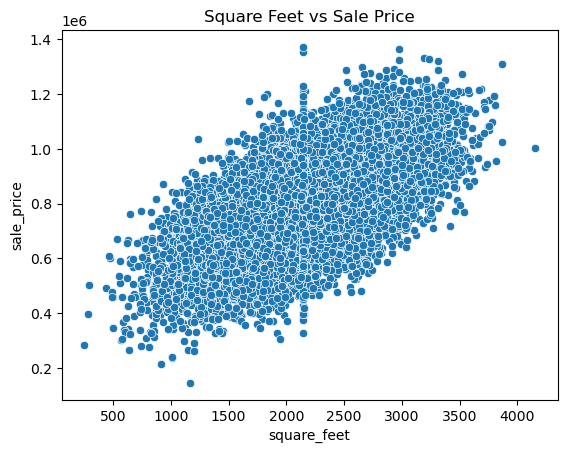

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="square_feet", y="sale_price", data=df)
plt.title("Square Feet vs Sale Price")

Text(0.5, 1.0, 'Lot Size vs Sale Price')

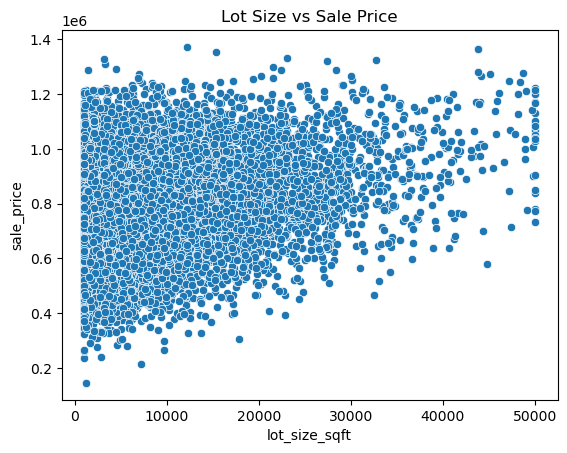

In [55]:
sns.scatterplot(x="lot_size_sqft", y="sale_price", data=df)
plt.title("Lot Size vs Sale Price")

Text(0.5, 1.0, 'Bedrooms vs Sale Price')

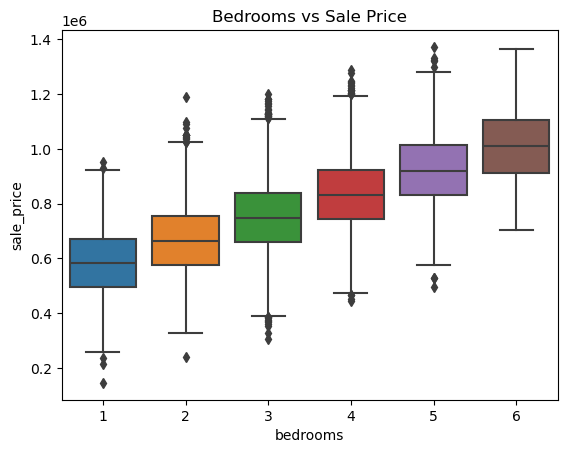

In [54]:
sns.boxplot(x="bedrooms", y="sale_price", data=df)
plt.title("Bedrooms vs Sale Price")

Text(0.5, 1.0, 'house_age to sale_price')

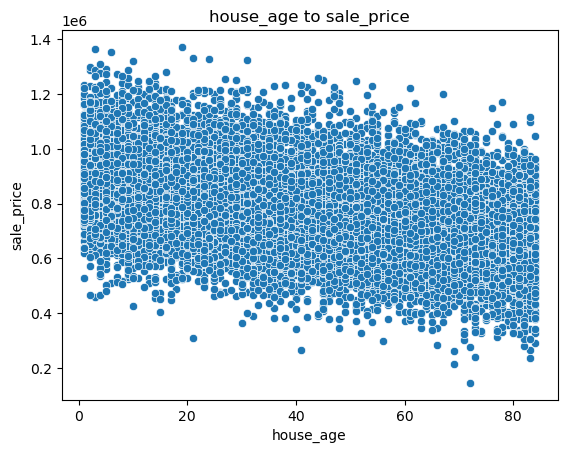

In [28]:
sns.scatterplot(x = "house_age",y = "sale_price",data = df)
plt.title("house_age to sale_price")

Text(0.5, 1.0, 'Years Since Renovation vs Price')

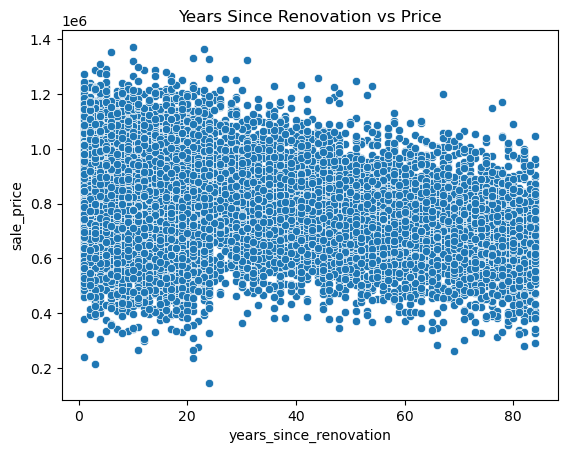

In [56]:
sns.scatterplot(x="years_since_renovation", y="sale_price", data=df)
plt.title("Years Since Renovation vs Price")

Text(0.5, 1.0, 'Total room vs Sale Price')

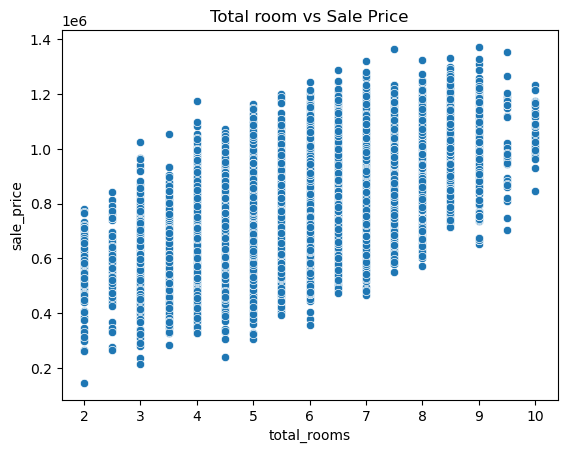

In [37]:
sns.scatterplot(x = "total_rooms", y = "sale_price", data = df)
plt.title("Total room vs Sale Price")

<Axes: >

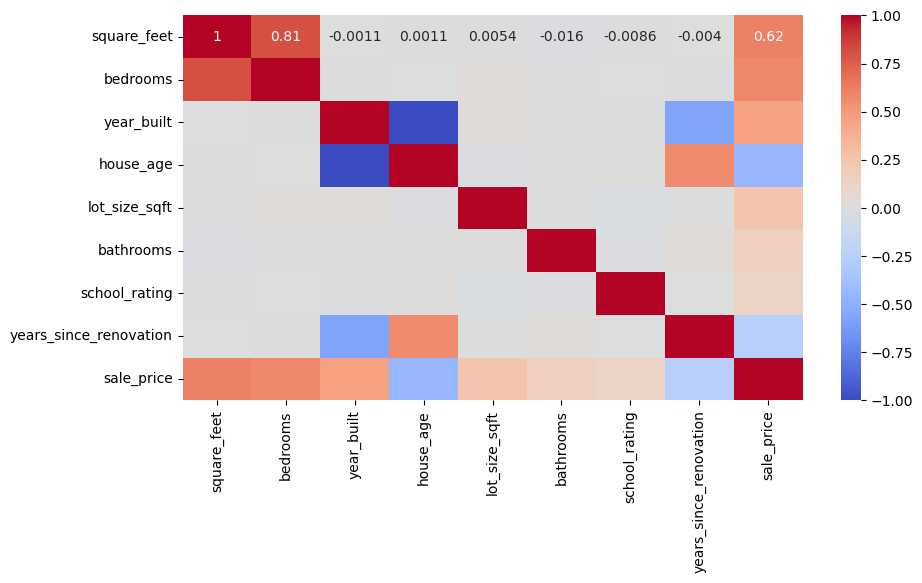

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(
    df[
        [
            "square_feet",
            "bedrooms",
            "year_built",
            "house_age",
            "lot_size_sqft",
            "bathrooms",
            "school_rating",
            "years_since_renovation",
            "sale_price"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

SQUARE FEET INCREASE SALES PRICE



In [41]:
from scipy import stats
 
r, p = stats.pearsonr(df["square_feet"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)
 
if p < 0.05:
    print("Reject H0 - square_feet is significant")
else:
    print("Fail to reject H0")

Correlation: 0.6150009379111865
p-value: 0.0
Reject H0 - square_feet is significant


AGE OF HOUSE AFFECTS PRICE

In [44]:
from scipy import stats
#  labels=['New','Moderate','Old','Very Old']
new = df[df['age_category'] == 'New']['sale_price']
moderate = df[df['age_category'] == 'Moderate']['sale_price']
old = df[df['age_category'] == 'Old']['sale_price']
very_old = df[df['age_category'] == 'Very Old']['sale_price']

f_stat, p_value = stats.f_oneway(new, moderate, old, very_old)

print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 — house age category affects price")
else:
    print("Fail to reject H0")

F-statistic: 1159.2101589454558
p-value: 0.0
Reject H0 — house age category affects price


TOTAL ROOM INCREASES THE SALES PRICE

In [46]:
from scipy import stats

r, p = stats.pearsonr(df["total_rooms"], df["sale_price"])

print("Correlation:", r)
print("p-value:", p)

if p < 0.05:
    print("Reject H0 — Total_rooms increases price")
else:
    print("Fail to reject H0")

Correlation: 0.5691111253006687
p-value: 0.0
Reject H0 — Total_rooms increases price


RENOVATION INCREASES THE PRICE

In [48]:
renovated = df[df['was_renovated']==1]['sale_price']
not_renovated = df[df['was_renovated']==0]['sale_price']
t_stat, p_val = stats.ttest_ind(renovated, not_renovated)
print("T-test:", t_stat, "p-value:", p_val)

print("Renovated mean:", renovated.mean())
print("Not renovated mean:", not_renovated.mean())
if p_val < 0.05: 
    print("Reject H0 - Renovation increases price")
else:
    print("Fail to reject H0")

T-test: -0.8792155455653475 p-value: 0.3792985031851731
Renovated mean: 781392.5655119322
Not renovated mean: 783743.1131099353
Fail to reject H0


In [49]:
features = [
    "high_value_property_yes",
    "square_feet",
    "total_rooms",
    "year_built",
    "house_age",
    "lot_size_sqft",
    "neighborhood_tier_premium",
    "school_rating",
    "kitchen_quality_premium",
    "years_since_renovation",

]

X = df[features]
y = df["sale_price"]

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
# from sklearn.ensemble import GradientBoostingRegressor

# model = GradientBoostingRegressor()
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [52]:
from sklearn.metrics import r2_score, mean_absolute_error

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2 Score: 0.828790925521358
MAE: 53656.34231451583
